Game 5 | Score: 25

Average Evaluation Score: 20.20


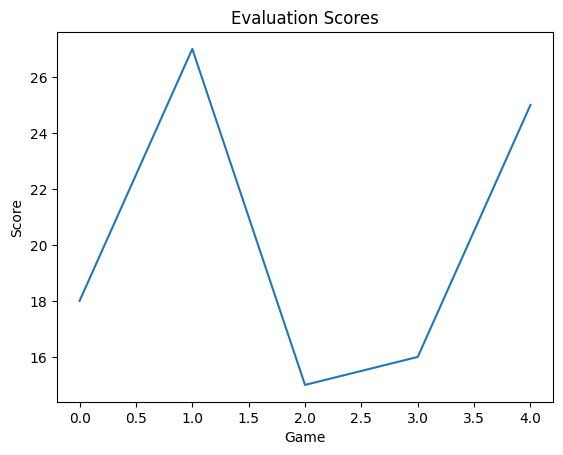


Final Average Test Score: 20.20


In [11]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import matplotlib.pyplot as plt
from matplotlib import colors
from IPython.display import clear_output, display
import time

class SnakeEnv:
    def __init__(self, size=8, max_steps=200, use_magnet=True):
        self.size = size
        self.max_steps = max_steps
        self.use_magnet = use_magnet
        self.magnet = None
        self.reset()

    def reset(self):
        self.snake = [(self.size // 2, self.size // 2)]
        self.direction = random.choice([(0,1),(1,0),(0,-1),(-1,0)])
        self.magnet = None
        self.magnet_active = 0 if self.use_magnet else None
        self.foods_eaten = 0
        self.score = 0
        self.steps = 0
        self.done = False
        self.spawn_food()
        return self.get_state()

    def spawn_food(self):
        empty = [(i,j) for i in range(self.size) for j in range(self.size)
                 if (i,j) not in self.snake and (i,j) != self.magnet]
        self.food = random.choice(empty)

    def spawn_magnet(self):
        empty = [(i,j) for i in range(self.size) for j in range(self.size)
                 if (i,j) not in self.snake and (i,j) != self.food]
        self.magnet = random.choice(empty) if empty else None

    def step(self, action):
        dir_map = [(0, -1), (1, 0), (0, 1), (-1, 0)]
        dir_idx = dir_map.index(self.direction)
        if action == 0:
            dir_idx = (dir_idx - 1) % 4
        elif action == 2:
            dir_idx = (dir_idx + 1) % 4
        self.direction = dir_map[dir_idx]

        head = (self.snake[0][0] + self.direction[0], self.snake[0][1] + self.direction[1])
        self.steps += 1

        if not (0 <= head[0] < self.size and 0 <= head[1] < self.size) or head in self.snake:
            self.done = True
            return self.get_state(), -10, self.done, {}

        self.snake.insert(0, head)
        reward = -0.1

        if self.use_magnet and self.magnet and head == self.magnet:
            self.magnet_active = 5
            self.magnet = None

        if head == self.food or (self.use_magnet and self.magnet_active > 0 and self.distance(head, self.food) == 1):
            reward = 10
            self.score += 1
            self.foods_eaten += 1
            self.spawn_food()
            if self.use_magnet and self.foods_eaten % 2 == 0:
                self.spawn_magnet()
        else:
            self.snake.pop()
            dist_now = self.distance(head, self.food)
            if len(self.snake) > 1:
                dist_prev = self.distance(self.snake[1], self.food)
            else:
                dist_prev = dist_now
            if dist_now < dist_prev:
                reward += 1
            else:
                reward -= 1

        if self.use_magnet:
            self.magnet_active = max(0, self.magnet_active - 1)

        if self.steps >= self.max_steps:
            self.done = True

        return self.get_state(), reward, self.done, {}

    def distance(self, a, b):
        return abs(a[0] - b[0]) + abs(a[1] - b[1])

    def get_state(self):
        head = self.snake[0]
        dir_x, dir_y = self.direction
        left = (-dir_y, dir_x)
        right = (dir_y, -dir_x)

        def danger(dx, dy):
            nx, ny = head[0] + dx, head[1] + dy
            return not (0 <= nx < self.size and 0 <= ny < self.size) or (nx, ny) in self.snake

        state = [
            int(danger(dir_x, dir_y)),
            int(danger(left[0], left[1])),
            int(danger(right[0], right[1])),
            int(self.direction == (0, -1)),
            int(self.direction == (1, 0)),
            int(self.direction == (0, 1)),
            int(self.direction == (-1, 0)),
            int(self.food[0] < head[0]),
            int(self.food[0] > head[0]),
            int(self.food[1] < head[1]),
            int(self.food[1] > head[1]),
            head[0] / (self.size - 1),
            head[1] / (self.size - 1),
            self.food[0] / (self.size - 1),
            self.food[1] / (self.size - 1),
            len(self.snake) / (self.size * self.size)
        ]
        return np.array(state, dtype=float)

    def render(self):
        grid = np.zeros((self.size, self.size))
        for (x, y) in self.snake:
            grid[x, y] = 0.5
        fx, fy = self.food
        grid[fx, fy] = 1.0
        if self.magnet:
            mx, my = self.magnet
            grid[mx, my] = 0.8

        cmap = colors.ListedColormap(['white', 'green', 'orange', 'blue'])
        bounds = [0, 0.4, 0.6, 0.9, 1.1]
        norm = colors.BoundaryNorm(bounds, cmap.N)

        plt.imshow(grid, cmap=cmap, norm=norm)
        plt.xticks([])
        plt.yticks([])
        plt.title(f"Score: {self.score} | Steps: {self.steps} | Magnet Active: {self.magnet_active if self.use_magnet else 0}")
        display(plt.gcf())
        clear_output(wait=True)
        time.sleep(0.05)
        plt.close()

    @property
    def observation_space(self):
        class O:
            shape = (16,)
        return O()

    @property
    def action_space(self):
        class A:
            n = 3
        return A()

class DQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, *args):
        self.buffer.append(tuple(args))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return map(np.array, zip(*batch))

    def __len__(self):
        return len(self.buffer)

def train_snake(num_episodes=50, render=False, use_magnet=True, return_logs=False):
    env = SnakeEnv(use_magnet=use_magnet)
    batch_size = 128
    gamma = 0.99
    lr = 1e-3
    buffer_capacity = 10000
    min_buffer_size = 1000
    epsilon = 1.0
    epsilon_min = 0.05
    epsilon_decay = 0.995
    target_update = 20

    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n
    policy_net = DQN(obs_dim, n_actions)
    target_net = DQN(obs_dim, n_actions)
    target_net.load_state_dict(policy_net.state_dict())
    optimizer = optim.Adam(policy_net.parameters(), lr=lr)
    replay_buffer = ReplayBuffer(buffer_capacity)

    all_rewards = []

    for episode in range(num_episodes):
        state = env.reset()
        total_reward = 0
        done = False

        while not done:
            if np.random.rand() < epsilon:
                action = random.randint(0, n_actions - 1)
            else:
                with torch.no_grad():
                    state_tensor = torch.FloatTensor(state).unsqueeze(0)
                    action = policy_net(state_tensor).argmax().item()

            next_state, reward, done, _ = env.step(action)
            replay_buffer.push(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward

            if render:
                env.render()

            if len(replay_buffer) > min_buffer_size:
                s, a, r, ns, d = replay_buffer.sample(batch_size)
                s = torch.FloatTensor(s)
                a = torch.LongTensor(a)
                r = torch.FloatTensor(r)
                ns = torch.FloatTensor(ns)
                d = torch.FloatTensor(d)
                q_values = policy_net(s).gather(1, a.unsqueeze(1)).squeeze()
                next_q = target_net(ns).max(1)[0]
                expected_q = r + gamma * next_q * (1 - d)
                loss = nn.MSELoss()(q_values, expected_q.detach())
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        all_rewards.append(total_reward)
        if episode % target_update == 0:
            target_net.load_state_dict(policy_net.state_dict())

        epsilon = max(epsilon * epsilon_decay, epsilon_min)
        print(f"Episode {episode} | Score: {env.score} | Total Reward: {total_reward:.2f} | Epsilon: {epsilon:.3f}")

    avg_reward = sum(all_rewards) / len(all_rewards)
    print(f"\nAverage Training Reward: {avg_reward:.2f}")
    plt.plot(all_rewards)
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.title("Training Rewards")
    plt.show()
    torch.save(policy_net.state_dict(), "best_snake_magnet_dqn.pth")
    if return_logs:
        return all_rewards, avg_reward

def eval_snake(n_games=3, use_magnet=True):
    env = SnakeEnv(use_magnet=use_magnet)
    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n
    policy_net = DQN(obs_dim, n_actions)
    policy_net.load_state_dict(torch.load("best_snake_magnet_dqn.pth"))
    policy_net.eval()
    scores = []

    for game in range(n_games):
        state = env.reset()
        done = False
        while not done:
            env.render()
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state).unsqueeze(0)
                action = policy_net(state_tensor).argmax().item()
            state, _, done, _ = env.step(action)
        print(f"Game {game+1} | Score: {env.score}")
        scores.append(env.score)

    avg_score = sum(scores) / len(scores)
    print(f"\nAverage Evaluation Score: {avg_score:.2f}")
    plt.plot(scores)
    plt.xlabel("Game")
    plt.ylabel("Score")
    plt.title("Evaluation Scores")
    plt.show()
    return scores, avg_score

if __name__ == "__main__":
    print("1. Train agent\n2. Evaluate agent")
    choice = input("Choose 1 or 2: ").strip()
    magnet_choice = input("Activate magnet? (y/n): ").strip().lower() == 'y'

    if choice == '1':
        rewards, avg = train_snake(num_episodes=1000, render=False, use_magnet=magnet_choice, return_logs=True)
        print(f"\nFinal Average Training Reward: {avg:.2f}")
    elif choice == '2':
        scores, avg = eval_snake(n_games=5, use_magnet=magnet_choice)
        print(f"\nFinal Average Test Score: {avg:.2f}")
